In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'lib')))
from renormalization import find_Jc

<>:30: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:30: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/p_/j__hv0j95yv8xknt5_nvt4pw0000gn/T/ipykernel_55787/507664285.py:30: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_title(f"Critical line on the $K_0={scan_kwargs['K0']}, \Delta_0={scan_kwargs['Delta0']}$ slice", fontsize=13)


a = 0.40   J_c = 0.0121   1/J_c = 82.9022
a = 0.48   J_c = 0.0288   1/J_c = 34.6660
a = 0.57   J_c = 0.1318   1/J_c = 7.5849
a = 0.65   J_c = 0.2493   1/J_c = 4.0107
a = 0.74   J_c = 0.3806   1/J_c = 2.6277
a = 0.82   J_c = 0.5247   1/J_c = 1.9057
a = 0.91   J_c = 0.6796   1/J_c = 1.4714
a = 0.99   J_c = 0.8452   1/J_c = 1.1832
a = 1.07   J_c = 1.0199   1/J_c = 0.9805
a = 1.16   J_c = 1.2022   1/J_c = 0.8318
a = 1.24   J_c = 1.3914   1/J_c = 0.7187
a = 1.33   J_c = 1.5883   1/J_c = 0.6296
a = 1.41   J_c = 1.7927   1/J_c = 0.5578
a = 1.49   J_c = 2.0048   1/J_c = 0.4988
a = 1.58   J_c = 2.2268   1/J_c = 0.4491
a = 1.66   J_c = 2.4588   1/J_c = 0.4067
a = 1.75   J_c = 2.7021   1/J_c = 0.3701
a = 1.83   J_c = 2.9585   1/J_c = 0.3380
a = 1.92   J_c = 3.2286   1/J_c = 0.3097
a = 2.00   J_c = 3.5154   1/J_c = 0.2845


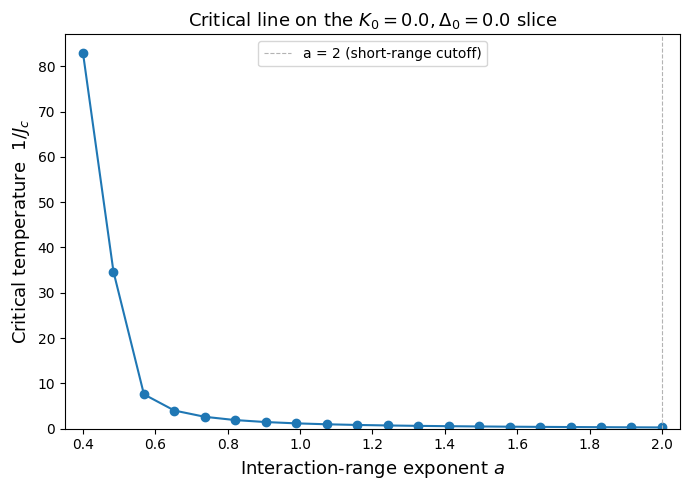

In [8]:
a_values = np.linspace(0.4, 2.0, 20)

# Bisection settings: keep max_steps modest and max_dist_final small for
# reasonable runtime. Tighten tol only if the plot looks noisy.
scan_kwargs = dict(
    K0=0.0, Delta0=0.0,
    
    Jlow=1e-3, Jhigh=50.0,
    max_steps=5, max_dist_final=6,
    tol=1e-3,
    growth_threshold=1e2, decay_threshold=1e-2,
)

# --- Run the scan ---
Jc_values = np.empty_like(a_values)
for i, a in enumerate(a_values):
    Jc = find_Jc(a, **scan_kwargs)
    Jc_values[i] = Jc
    print(f"a = {a:.2f}   J_c = {Jc:.4f}   1/J_c = {1/Jc:.4f}")

inv_Jc = 1.0 / Jc_values

<>:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/p_/j__hv0j95yv8xknt5_nvt4pw0000gn/T/ipykernel_55787/2456248900.py:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_title(f"Critical line on the $K_0={scan_kwargs['K0']}, \Delta_0={scan_kwargs['Delta0']}$ slice", fontsize=13)


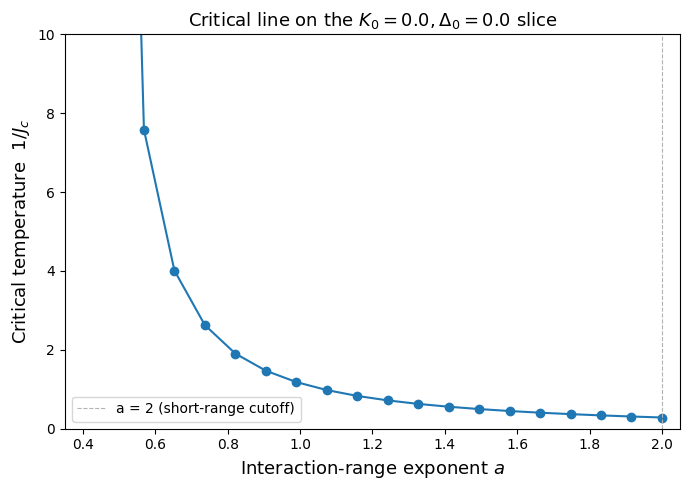

In [15]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(a_values, inv_Jc, marker='o', linewidth=1.5, color='C0')
ax.axvline(2.0, color='0.7', linestyle='--', linewidth=0.8, label='a = 2 (short-range cutoff)')
ax.set_xlabel(r"Interaction-range exponent $a$", fontsize=13)
ax.set_ylabel(r"Critical temperature  $1/J_c$", fontsize=13)
ax.set_title(f"Critical line on the $K_0={scan_kwargs['K0']}, \Delta_0={scan_kwargs['Delta0']}$ slice", fontsize=13)
#ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(a_values[0] - 0.05, a_values[-1] + 0.05)
ax.set_ylim(0, 10)
plt.tight_layout()
#plt.savefig("../results/critical_line.png", dpi=150)
plt.show()